<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg" align="left">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">Supervivencia en Cáncer de Mama y Pulmón</p>
<p style="margin: 0; text-align:right;">2026-1 · Máster universitario en Ciencia de datos (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudios de Informática, Multimedia y Telecomunicación</p>
<p style="margin: 0; text-align:right;">Julio Úbeda Quesada</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>

<div class="alert alert-block alert-info">
<strong>Nombre y apellidos: JULIO ÚBEDA QUESADA</strong>
</div>

# Análisis de Supervivencia y Predicción de Riesgo Clínico: Estudio Comparativo en Cáncer de Mama y Pulmón

Este notebook continúa el trabajo de EDA y preprocesamiento ya realizado sobre **METABRIC** y carga directamente los artefactos generados al final del notebook anterior:

- `X_train_df.parquet`, `X_test_df.parquet`
- `X_train_np.npy`, `X_test_np.npy`
- `dur_train.npy`, `dur_test.npy`
- `evt_train.npy`, `evt_test.npy`
- `y_train.pkl`, `y_test.pkl` *(opcional; se reconstruye desde duración/evento para evitar problemas de compatibilidad)*

Se implementan y comparan cuatro enfoques de análisis de supervivencia:

1. **Kaplan-Meier estratificado** como baseline interpretable.
2. **Cox penalizado LASSO** (`CoxnetSurvivalAnalysis`, penalización L1).
3. **Random Survival Forest**.
4. **DeepSurv** mediante `pycox`/`PyTorch`.

Las métricas principales son:

- **C-index de Harrell**: mayor es mejor.
- **C-index IPCW/Uno**: mayor es mejor, corrige parcialmente la censura.
- **Integrated Brier Score (IBS)**: menor es mejor.
- **Log-rank test** entre grupos de alto y bajo riesgo: p-valor bajo indica separación significativa de curvas.

# **1 Diseño e Implementación de Modelos**

Una vez finalizado el preprocesamiento de la cohorte METABRIC y definida la variable objetivo de supervivencia (`duration`, `event`), se inicia la fase de modelado. El objetivo de esta sección es implementar de forma progresiva distintos enfoques de análisis de supervivencia, empezando por métodos clásicos e interpretables y avanzando posteriormente hacia modelos multivariantes y no lineales.

El flujo de modelado se estructura en cuatro familias metodológicas:

1. **Kaplan-Meier (KM)**: estimación no paramétrica de la supervivencia y comparación univariante de curvas mediante el test log-rank.
2. **Cox proporcional penalizado**: modelo semiparamétrico multivariante para estimar el efecto ajustado de las covariables.
3. **Random Survival Forest (RSF)**: modelo de aprendizaje automático capaz de capturar relaciones no lineales e interacciones.
4. **DeepSurv**: arquitectura de aprendizaje profundo basada en la función de pérdida de Cox.

En este primer apartado se desarrolla únicamente el estimador de Kaplan-Meier, que se utilizará como punto de partida descriptivo y como modelo basal de comparación.

In [46]:
import warnings
warnings.filterwarnings('ignore')

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
from itertools import combinations
from statsmodels.stats.outliers_influence import variance_inflation_factor

# scikit-survival
from sksurv.util import Surv
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import (
    concordance_index_censored,
    brier_score,
    integrated_brier_score
)

# lifelines (forest plot Cox)
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import proportional_hazard_test
from matplotlib.lines import Line2D

# Validación cruzada
from sklearn.model_selection import StratifiedKFold

# Deep Learning
import torch
import torch.nn as nn
import torchtuples as tt
from pycox.models import CoxPH as DeepSurvModel

# Configuración del entorno
warnings.filterwarnings('ignore')

# Ruta raíz (útil en notebooks)
root_dir = os.path.abspath('..')
sys.path.append(root_dir)

# Configuración de pandas
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Info entorno
print("✓ Imports completados.")
print(f"  PyTorch  : {torch.__version__}")
print(f"  CUDA     : {'disponible' if torch.cuda.is_available() else 'no disponible — CPU'}")

✓ Imports completados.
  PyTorch  : 2.10.0+cpu
  CUDA     : no disponible — CPU


In [33]:
# Importa y actualiza las funciones personalizadas desde utils.
import importlib
import utils.KMmodel_functions as KM
import utils.Coxmodel_functions as Cox
importlib.reload(KM)
importlib.reload(Cox)

<module 'utils.Coxmodel_functions' from 'c:\\Users\\usuario\\Documents\\GitHub\\TFM---Analisis-de-supervivencia-del-cancer\\Modulo 3 - Diseño e implementacion del trabajo\\utils\\Coxmodel_functions.py'>

In [3]:
SAVE_DIR = '../data/processed/metabric'

# Cargar el CSV en un nuevo DataFrame
brca_prep = pd.read_csv(f'{SAVE_DIR}/brca_metabric_preprocessed.csv')

# Cargar los datos preprocesados
X_train_np = np.load(f'{SAVE_DIR}/X_train_np.npy')
X_test_np  = np.load(f'{SAVE_DIR}/X_test_np.npy')
dur_train  = np.load(f'{SAVE_DIR}/dur_train.npy')
dur_test   = np.load(f'{SAVE_DIR}/dur_test.npy')
evt_train  = np.load(f'{SAVE_DIR}/evt_train.npy')
evt_test   = np.load(f'{SAVE_DIR}/evt_test.npy')
y_train    = joblib.load(f'{SAVE_DIR}/y_train.pkl')
y_test     = joblib.load(f'{SAVE_DIR}/y_test.pkl')
X_train    = pd.read_parquet(f'{SAVE_DIR}/X_train_df.parquet')
X_test     = pd.read_parquet(f'{SAVE_DIR}/X_test_df.parquet')

print('Datos cargados correctamente:')
print(f'\t- brca_prep : {brca_prep.shape}')
print(f'\t- X_train_np : {X_train_np.shape}')
print(f'\t- X_test_np  : {X_test_np.shape}')
print(f'\t- y_train    : {y_train.dtype}  {y_train.shape}')
print(f'\t- Tasa eventos train : {evt_train.mean():.2%}')
print(f'\t- Tasa eventos test  : {evt_test.mean():.2%}')

Datos cargados correctamente:
	- brca_prep : (1981, 23)
	- X_train_np : (1584, 56)
	- X_test_np  : (397, 56)
	- y_train    : [('event', '?'), ('time', '<f8')]  (1584,)
	- Tasa eventos train : 57.77%
	- Tasa eventos test  : 57.68%


## **1.1. Estimador de Kaplan-Meier (KM)**

Es el método no paramétrico estándar para estimar la función de supervivencia $S(t) = P(T > t)$ sin asumir una distribución previa de los datos. En este trabajo, el evento se define como la muerte por cualquier causa (`Overall Survival`).

El modelo cumple tres funciones principales:
1. **Descriptiva:** Visualizar la supervivencia global de la cohorte METABRIC.
2. **Exploratoria:** Comparar subgrupos mediante el **test log-rank**, que contrasta la hipótesis nula $H_0: S_1(t) = S_2(t) = \cdots = S_k(t)$. El estadístico sigue una distribución $\chi^2$ y es especialmente potente bajo riesgos proporcionales.
3. **Predictiva (Basal):** Servir como modelo marginal de referencia (ajustado solo en *train*) para establecer un umbral mínimo de `Integrated Brier Score` frente al cual comparar los modelos multivariantes.



### **1.1.1. Discretización de variables continuas para Kaplan-Meier**

Para permitir el análisis univariante, variables continuas como la edad o el NPI se discretizan en categorías clínicas o cuartiles. Esta transformación es exclusiva para Kaplan-Meier; los modelos Cox, RSF y DeepSurv utilizarán las variables originales para preservar su valor predictivo.

In [4]:
df_km = brca_prep.copy()

# ── 1. Age at Diagnosis ───────────────────────────────────────────────────────
# Franjas etarias estándar en oncología mamaria.
# Referencia: Partridge et al., JCO 2016; SEER Age Groups.
df_km['Age Group'] = pd.cut(
    df_km['Age at Diagnosis'],
    bins   = [0, 40, 50, 60, 70, np.inf],
    labels = ['<40', '40–49', '50–59', '60–69', '≥70'],
    right  = False
)
print("── Age Group ────────────────────────────────────────")
print(df_km['Age Group'].value_counts().sort_index())

# ── 2. Tumor Stage ────────────────────────────────────────────────────────────
# Valores 0–4 → estadios TNM clínicos.
# Referencia: AJCC Cancer Staging Manual, 8ª ed.
df_km['Tumor Stage Cat'] = (
    df_km['Tumor Stage']
    .astype('Int64')
    .astype(str)
    .replace('<NA>', np.nan)
    .apply(lambda x: f'Stage {x}' if pd.notna(x) and x != 'nan' else np.nan)
    .astype('category')
)
print("\n── Tumor Stage Cat ──────────────────────────────────")
print(df_km['Tumor Stage Cat'].value_counts().sort_index())

# ── 3. Neoplasm Histologic Grade ──────────────────────────────────────────────
# Sistema Scarff-Bloom-Richardson (SBR) / Nottingham.
# Referencia: Elston & Ellis, Histopathology 1991.
grade_map = {
    1.0: 'G1 — Bien diferenciado',
    2.0: 'G2 — Moderado',
    3.0: 'G3 — Pobremente diferenciado'
}
df_km['Histologic Grade Cat'] = df_km['Neoplasm Histologic Grade'].map(grade_map).astype('category')

print("\n── Histologic Grade Cat ─────────────────────────────")
print(df_km['Histologic Grade Cat'].value_counts().sort_index())

# ── 4. Lymph nodes examined positive — Clasificación N del TNM ───────────────
# Referencia: AJCC 8ª ed.; Giuliano et al., JCO 2017.
df_km['Nodal Status'] = pd.cut(
    df_km['Lymph nodes examined positive'],
    bins   = [-np.inf, 0, 3, 9, np.inf],
    labels = ['N0 (0)', 'N1 (1–3)', 'N2 (4–9)', 'N3 (≥10)'],
    right  = True
)

print("\n── Nodal Status ─────────────────────────────────────")
print(df_km['Nodal Status'].value_counts().sort_index())

# ── 5. Nottingham Prognostic Index ────────────────────────────────────────────
# Puntos de corte de Haybittle-Galea.
# Referencia: Galea et al., Breast Cancer Res Treat 1992.
df_km['NPI Group'] = pd.cut(
    df_km['Nottingham prognostic index'],
    bins   = [0, 3.4, 5.4, np.inf],
    labels = ['NPI ≤3.4 (buen pronóstico)',
              'NPI 3.4–5.4 (pronóstico moderado)',
              'NPI >5.4 (mal pronóstico)'],
    right  = True
)

print("\n── NPI Group ────────────────────────────────────────")
print(df_km['NPI Group'].value_counts().sort_index())

# ── 6. TMB (nonsynonymous) ─────────────────────────────────────────────────────────
# Sin consenso clínico para mama primario → cuartiles del dataset.
# Referencia: Alexandrov et al., Nature 2013.
p25 = df_km['TMB (nonsynonymous)'].quantile(0.25)  # = 3.0
p50 = df_km['TMB (nonsynonymous)'].quantile(0.50)  # = 5.0
p75 = df_km['TMB (nonsynonymous)'].quantile(0.75)  # = 7.0

df_km['Mutation Burden'] = pd.cut(
    df_km['TMB (nonsynonymous)'],
    bins           = [0, p25, p50, p75, np.inf],
    labels         = ['Q1 — Baja (≤3)', 'Q2 — Moderada-baja (3–5)',
                      'Q3 — Moderada-alta (5–7)', 'Q4 — Alta (>7)'],
    right          = True,
    include_lowest = True
)

print("\n── Mutation Burden ──────────────────────────────────")
print(df_km['Mutation Burden'].value_counts().sort_index())

# ── Resumen ───────────────────────────────────────────────────────────────────
VARS_KM_DISC = ['Age Group', 'Tumor Stage Cat', 'Histologic Grade Cat',
                'Nodal Status', 'NPI Group', 'Mutation Burden']
print('\n')
print('═' * 58)
print('  VARIABLES DISCRETIZADAS PARA KM')
print('═' * 58)
for var in VARS_KM_DISC:
    print(f'  {var:<35} k={df_km[var].nunique()}  '
          f'nulos={df_km[var].isna().sum()}')
print('═' * 58)

── Age Group ────────────────────────────────────────
Age Group
<40      120
40–49    304
50–59    449
60–69    576
≥70      532
Name: count, dtype: int64

── Tumor Stage Cat ──────────────────────────────────
Tumor Stage Cat
Stage 0     12
Stage 1    501
Stage 2    825
Stage 3    118
Stage 4     10
Name: count, dtype: int64

── Histologic Grade Cat ─────────────────────────────
Histologic Grade Cat
G1 — Bien diferenciado          169
G2 — Moderado                   771
G3 — Pobremente diferenciado    953
Name: count, dtype: int64

── Nodal Status ─────────────────────────────────────
Nodal Status
N0 (0)      994
N1 (1–3)    604
N2 (4–9)    204
N3 (≥10)    103
Name: count, dtype: int64

── NPI Group ────────────────────────────────────────
NPI Group
NPI ≤3.4 (buen pronóstico)            680
NPI 3.4–5.4 (pronóstico moderado)    1101
NPI >5.4 (mal pronóstico)             199
Name: count, dtype: int64

── Mutation Burden ──────────────────────────────────
Mutation Burden
Q1 — Baja (≤3)   

### **1.1.2. Supervivencia global de la cohorte METABRIC**

En primer lugar, se ajusta una curva Kaplan-Meier no estratificada sobre la cohorte completa con endpoint de supervivencia global. Esta curva resume la probabilidad estimada de supervivencia de la población METABRIC a lo largo del seguimiento.

In [5]:
dur_all = df_km['duration'].values
evt_all = df_km['event'].values.astype(bool)

print(f'Cohorte KM  : {len(df_km):,} pacientes')
print(f'Eventos     : {evt_all.sum():,} ({evt_all.mean():.1%})')
print(f'Censurados  : {(~evt_all).sum():,} ({(~evt_all).mean():.1%})')
print(f'Seguimiento : {dur_all.min():.1f} – {dur_all.max():.1f} meses')

Cohorte KM  : 1,981 pacientes
Eventos     : 1,144 (57.7%)
Censurados  : 837 (42.3%)
Seguimiento : 0.0 – 355.2 meses


La cohorte incluye 1.981 pacientes con información válida de supervivencia global, de los cuales 1.144 presentan el evento de muerte y 837 corresponden a observaciones censuradas. Esto implica una tasa de eventos del 57,7%, suficiente para realizar análisis de supervivencia con estabilidad razonable.

In [6]:
kmf_global = KM.fit_km_global(
    dur_all,
    evt_all,
    label="METABRIC — Cohorte completa"
)

display(
    KM.km_metrics(
        kmf_global,
        horizons=[60, 120, 180, 240]
    )
)

KM.plot_km_global(
    kmf=kmf_global,
    n_total=len(df_km),
    group_name="Supervivencia Global",
    dataset_name="METABRIC",
    output_path=r"../images/Modelos/KM"
)

,Métrica,Valor
0,Mediana supervivencia (meses),156.3
1,S(t=60m) [5 años],0.780
2,S(t=120m) [10 años],0.593
3,S(t=180m) [15 años],0.445
4,S(t=240m) [20 años],0.294


✔ KM global guardado en: ../images/Modelos/KM\METABRIC_km_global_Supervivencia_Global.html


### **1.1.3. Test log-rank univariante**

Se emplea el **test log-rank de Mantel-Cox** para contrastar la igualdad de las funciones de supervivencia entre $k$ grupos:

$$H_0: S_1(t) = S_2(t) = \cdots = S_k(t)$$
$$H_1: \exists \, i, j \mid S_i(t) \neq S_j(t)$$

El estadístico compara los eventos observados ($O_{ij}$) frente a los esperados ($E_{ij}$) bajo la hipótesis nula:

$$\chi^2_{LR} = \frac{\left(\sum_j (O_{ij} - E_{ij})\right)^2}{\sum_j V_{ij}}$$

Bajo $H_0$, el estadístico sigue una distribución $\chi^2$ con $k-1$ grados de libertad. Este test es óptimo cuando los riesgos son **proporcionales** entre los grupos comparados.

Dada su naturaleza univariante, este análisis tiene un carácter estrictamente **exploratorio**. No se utilizará como criterio excluyente para la selección de variables, ya que los modelos multivariantes posteriores (Cox, RSF y DeepSurv).

In [7]:
VARS_LOGRANK = [
    # Biomarcadores moleculares
    'ER Status',
    'PR Status',
    'HER2 Status',
    'Pam50 + Claudin-low subtype',
    '3-Gene classifier subtype',
    'Integrative Cluster',
    # Patología tumoral — categóricas originales
    'Cancer Type Detailed',
    'Tumor Other Histologic Subtype',
    'Cellularity',
    # Patología tumoral — discretizadas
    'Tumor Stage Cat',
    'Histologic Grade Cat',
    'Nodal Status',
    'NPI Group',
    # Terapéuticas
    'Chemotherapy',
    'Hormone Therapy',
    'Radio Therapy',
    'Type of Breast Surgery',
    # Clínico-demográficas — categóricas originales
    'Inferred Menopausal State',
    'Primary Tumor Laterality',
    # Clínico-demográficas — discretizadas
    'Age Group',
    # Moleculares — discretizadas
    'Mutation Burden',
]

tabla_lr = KM.logrank_summary(df_km, VARS_LOGRANK)
display(tabla_lr)

,Variable,k grupos,chi²,p-valor,Significancia
0,Pam50 + Claudin-low subtype,7,56.036,0.000000,***
1,3-Gene classifier subtype,4,40.871,0.000000,***
2,Integrative Cluster,11,72.636,0.000000,***
3,Tumor Stage Cat,5,128.221,0.000000,***
4,Type of Breast Surgery,2,49.552,0.000000,***
5,NPI Group,3,156.127,0.000000,***
6,Nodal Status,4,205.501,0.000000,***
7,Inferred Menopausal State,2,40.349,0.000000,***
8,Age Group,5,201.502,0.000000,***
9,Histologic Grade Cat,3,26.399,0.000008,***


El test de log-rank cuantifica si hay diferencias, pero la visualización de las curvas de Kaplan-Meier permite comprender la *dinámica temporal* de esas diferencias. A continuación, se analizan los hallazgos agrupados por contexto clínico:

##### **I. Perfil Clínico-Demográfico**

La variable `Age Group` evidencia que la supervivencia decae de forma escalonada a medida que avanza la edad al diagnóstico, siendo el grupo de mayores de 70 años el de peor pronóstico con diferencia. Este efecto está íntimamente ligado al `Estado Menopáusico`, donde las pacientes postmenopáusicas muestran peor supervivencia. Por otro lado, la variable `Lateralidad del Tumor` (mama izquierda vs. derecha) presenta curvas prácticamente superpuestas ($p=0.71$), confirmando que la localización anatómica simétrica no influye en la biología de la enfermedad ni en el pronóstico.

In [41]:
grupos_config = {
    "Age Group": ("Age Group", "viridis"),
    "Inferred Menopausal State": ("Inferred Menopausal State", "Set2"),
    "Primary Tumor Laterality": ("Primary Tumor Laterality", "Set2"),
}

KM.plot_km_groups(
    df=df_km,
    grupos_config=grupos_config,
    group_name="Perfil Clinico-Demografico",
    dataset_name="METABRIC",
    output_path=r"..\images\Modelos\KM",
    ncols=2
)

✔ KM subplots guardado en: ..\images\Modelos\KM\METABRIC_km_subplots_Perfil_Clinico-Demografico.html


##### **II. Estadificación y Patología (Carga tumoral)**

Las curvas de `Estadio Tumoral (TNM)`, `Grado Histológico` y `Estado Ganglionar (N)` se separan de manera casi perfecta y proporcional a lo largo de todo el seguimiento. Un paciente en Estadio 0/1 o sin ganglios afectados (N0) mantiene una probabilidad de supervivencia superior al 80% a los 10 años, mientras que aquellos con 10 o más ganglios afectados (N3) o Grado 3 ven su curva desplomarse drásticamente en los primeros 5 años. Esta separación sin cruces sugiere fuertemente que estas variables cumplirán el supuesto de riesgos proporcionales necesario para el posterior modelo de Cox.

In [42]:
grupos_config = {
        'Tumor Stage Cat'         : ('Tumor Stage Cat',              'RdYlGn_r'),
        'Histologic Grade Cat'       : ('Histologic Grade Cat',         'RdYlGn_r'),
        'Nodal Status'         : ('Nodal Status',                 'RdYlGn_r'),
        'Cancer Type Detailed'          : ('Cancer Type Detailed',         'tab20'),
        'Cellularity'                   : ('Cellularity',                  'RdYlGn_r'),
    }

KM.plot_km_groups(
    df=df_km,
    grupos_config=grupos_config,
    group_name="Estadificación y Patología",
    dataset_name="METABRIC",
    output_path=r"..\images\Modelos\KM",
    ncols=2
)

✔ KM subplots guardado en: ..\images\Modelos\KM\METABRIC_km_subplots_Estadificacin_y_Patologa.html


##### **III. Biomarcadores de Receptor**

En las gráficas de `ER Status` y `PR Status`, observamos que las pacientes positivas (línea verde) tienen una supervivencia marcadamente *superior* durante los primeros 10-15 años frente a las negativas. Sin embargo, a partir del mes 150-200, las curvas convergen y llegan a cruzarse, indicando que los tumores Luminales (ER+) presentan un riesgo sostenido de recaída y mortalidad a muy largo plazo. Mientras que los tumores negativos tienen una mortalidad muy alta y temprana, pero si superan los primeros años, su riesgo de evento cae drásticamente. 

In [43]:
grupos_config = {
        'ER Status'               : ('ER Status',               'RdYlGn'),
        'PR Status'               : ('PR Status',               'RdYlGn'),
        'HER2 Status'             : ('HER2 Status',             'RdYlGn'),
    }

KM.plot_km_groups(
    df=df_km,
    grupos_config=grupos_config,
    group_name="Biomarcadores de Receptor",
    dataset_name="METABRIC",
    output_path=r"..\images\Modelos\KM",
    ncols=2
)

✔ KM subplots guardado en: ..\images\Modelos\KM\METABRIC_km_subplots_Biomarcadores_de_Receptor.html


##### IV. Subtipos Moleculares

Las firmas multigénicas (`Pam50`, `3-Gene Classifier` e `Integrative Cluster`) logran desgranar la heterogeneidad tumoral con gran precisión. En el gráfico de `Pam50`, destaca la rápida caída inicial de los subtipos *Her2* y *Basal*, en contraste con la caída más suave y prolongada del subtipo *Luminal A*. El `Integrative Cluster`, al dividir la cohorte en 10 subgrupos, genera un abanico que, aunque visualmente denso, resalta la variable agresividad intrínseca del cáncer de mama.

In [44]:
grupos_config = {
        'Pam50 + Claudin-low subtype' : ('Pam50 + Claudin-low subtype', 'tab10'),
        '3-Gene classifier subtype'   : ('3-Gene classifier subtype',   'Set2'),
        'Integrative Cluster'         : ('Integrative Cluster',         'tab20'),
    }

KM.plot_km_groups(
    df=df_km,
    grupos_config=grupos_config,
    group_name="Subtipos Moleculares",
    dataset_name="METABRIC",
    output_path=r"..\images\Modelos\KM",
    ncols=2
)

✔ KM subplots guardado en: ..\images\Modelos\KM\METABRIC_km_subplots_Subtipos_Moleculares.html


##### V. Intervenciones Terapéuticas 

Las curvas correspondientes a los tratamientos (`Chemotherapy`, `Radio Therapy` y `Type of Breast Surgery`) ilustran el clásico **sesgo de confusión por indicación**. A simple vista, las gráficas sugieren contraintuitivamente que recibir quimioterapia o someterse a una mastectomía confiere *peor* supervivencia que no hacerlo o recibir cirugía conservadora. Clínicamente, esto no significa que el tratamiento sea perjudicial, sino que la quimioterapia y la cirugía radical se prescriben precisamente a pacientes que ya presentan tumores más grandes, de mayor grado o con ganglios positivos (peor pronóstico basal). 

In [45]:
grupos_config = {
        'Chemotherapy'        : ('Chemotherapy',       'Set1'),
        'Hormone Therapy'     : ('Hormone Therapy',    'Set1'),
        'Radio Therapy'       : ('Radio Therapy',      'Set1'),
        'Type of Breast Surgery': ('Type of Breast Surgery', 'Set2'),
    }

KM.plot_km_groups(
    df=df_km,
    grupos_config=grupos_config,
    group_name="Intervenciones Terapéuticas ",
    dataset_name="METABRIC",
    output_path=r"..\images\Modelos\KM",
    ncols=2
)

✔ KM subplots guardado en: ..\images\Modelos\KM\METABRIC_km_subplots_Intervenciones_Teraputicas_.html


### **1.1.4. Kaplan-Meier como modelo basal para Brier Score**

Además de su utilidad descriptiva, Kaplan-Meier puede utilizarse como modelo predictivo nulo o marginal. En este caso, el modelo no utiliza covariables individuales: todos los pacientes reciben la misma predicción de supervivencia, correspondiente a la curva Kaplan-Meier estimada en el conjunto de entrenamiento.

Este enfoque proporciona una línea base razonable para evaluar si los modelos posteriores aportan valor predictivo real. Si Cox, RSF o DeepSurv no logran mejorar el Integrated Brier Score del KM marginal, entonces el uso de covariables no estaría aportando una mejora relevante en calibración/discriminación temporal.

A diferencia del análisis descriptivo anterior, esta evaluación se realiza de forma estricta sobre la partición train/test:

1. Se ajusta Kaplan-Meier únicamente con `dur_train` y `evt_train`.
2. Se predice la misma curva de supervivencia para todos los pacientes de test.
3. Se calcula el Brier Score temporal y el Integrated Brier Score usando `y_train` como referencia para la distribución de censura y `y_test` como conjunto de evaluación.

Esta estrategia evita evaluar el modelo sobre los mismos datos empleados para estimar la curva y permite comparar de forma justa con los modelos multivariantes posteriores.

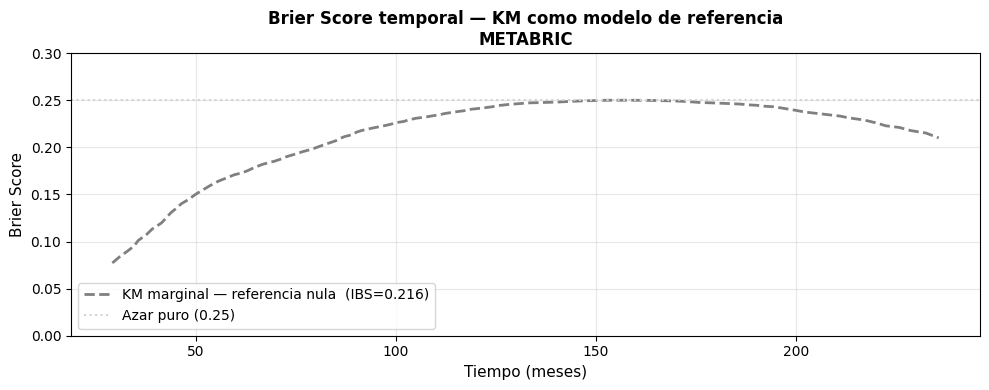

IBS — KM marginal (referencia nula) : 0.2156
  -> Cualquier modelo con IBS < 0.2156 mejora sobre la referencia KM


In [8]:
y_all      = Surv.from_arrays(evt_all.astype(bool), dur_all.astype(float))
times_ref  = np.percentile(dur_all, np.linspace(10, 90, 100))
times_ref  = times_ref[(times_ref > dur_all.min()) & (times_ref < dur_all.max())]

# Misma S(t) para todos los pacientes en cada instante
km_surv_probs = np.tile(
    kmf_global.predict(times_ref),
    (len(df_km), 1)
)

_, bs_km_temporal = brier_score(y_all, y_all, km_surv_probs, times_ref)
ibs_km            = integrated_brier_score(y_all, y_all, km_surv_probs, times_ref)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(times_ref, bs_km_temporal, color='gray', linewidth=2,
        linestyle='--', label=f'KM marginal — referencia nula  (IBS={ibs_km:.3f})')
ax.axhline(0.25, color='lightgray', linestyle=':', linewidth=1.5,
           label='Azar puro (0.25)')
ax.set_xlabel('Tiempo (meses)', fontsize=11)
ax.set_ylabel('Brier Score', fontsize=11)
ax.set_title('Brier Score temporal — KM como modelo de referencia\nMETABRIC',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 0.30)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(r'../images/Modelos/KM/KM_brier_referencia.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"IBS — KM marginal (referencia nula) : {ibs_km:.4f}")
print(f"  -> Cualquier modelo con IBS < {ibs_km:.4f} mejora sobre la referencia KM")

In [9]:
mediana_global = kmf_global.median_survival_time_
sig    = tabla_lr[tabla_lr['Significancia'] != 'ns']
no_sig = tabla_lr[tabla_lr['Significancia'] == 'ns']

print('═' * 65)
print('  RESULTADOS — Kaplan-Meier · METABRIC (n = 1.981)')
print('═' * 65)
print(f'  Mediana de supervivencia        : {mediana_global:.1f} m ({mediana_global/12:.1f} años)')
print(f'  S(t=60m)   — supervivencia  5a  : {kmf_global.predict(60):.3f}')
print(f'  S(t=120m)  — supervivencia 10a  : {kmf_global.predict(120):.3f}')
print(f'  S(t=180m)  — supervivencia 15a  : {kmf_global.predict(180):.3f}')
print(f'  S(t=240m)  — supervivencia 20a  : {kmf_global.predict(240):.3f}')
print(f'  IBS de referencia nula (KM)     : {ibs_km:.4f}')
print()
print(f'  Variables significativas (p < 0.05) : {len(sig)} / {len(tabla_lr)}')
for _, r in sig.iterrows():
    print(f'    {r["Significancia"]:<4} {r["Variable"]:<48} χ²={r["chi²"]:>8.3f}  p={r["p-valor"]:.2e}')
print()
print(f'  Variables no significativas (p ≥ 0.05) : {len(no_sig)} / {len(tabla_lr)}')
for _, r in no_sig.iterrows():
    print(f'    ns   {r["Variable"]:<48} χ²={r["chi²"]:>8.3f}  p={r["p-valor"]:.4f}')
print('═' * 65)

═════════════════════════════════════════════════════════════════
  RESULTADOS — Kaplan-Meier · METABRIC (n = 1.981)
═════════════════════════════════════════════════════════════════
  Mediana de supervivencia        : 156.3 m (13.0 años)
  S(t=60m)   — supervivencia  5a  : 0.780
  S(t=120m)  — supervivencia 10a  : 0.593
  S(t=180m)  — supervivencia 15a  : 0.445
  S(t=240m)  — supervivencia 20a  : 0.294
  IBS de referencia nula (KM)     : 0.2156

  Variables significativas (p < 0.05) : 16 / 20
    ***  Pam50 + Claudin-low subtype                      χ²=  56.036  p=0.00e+00
    ***  3-Gene classifier subtype                        χ²=  40.871  p=0.00e+00
    ***  Integrative Cluster                              χ²=  72.636  p=0.00e+00
    ***  Tumor Stage Cat                                  χ²= 128.221  p=0.00e+00
    ***  Type of Breast Surgery                           χ²=  49.552  p=0.00e+00
    ***  NPI Group                                        χ²= 156.127  p=0.00e+00
    ***  

### **1.1.5. Interpretación de los resultados**

#### I. Supervivencia global

La mediana de 156.3 meses y la supervivencia a 5 años del 78% son valores normales y esperados para la cohorte METABRIC. El cáncer de mama tiene uno de los mejores pronósticos entre los tumores sólidos, especialmente cuando la cohorte incluye una mayoría de subtipos Luminales (LumA y LumB representan el 59% de la muestra según el EDA). Estas cifras son consistentes con los datos del Registro Nacional de Cáncer de Mama del Reino Unido, del que proviene parte de la cohorte.

El IBS de referencia nula de **0.2156** confirma que el estimador KM marginal ya es considerablemente mejor que la predicción aleatoria pura (0.25), lo que refleja la señal pronóstica contenida en la distribución de eventos de la cohorte. Cualquier modelo predictivo debe alcanzar IBS < 0.2156 para justificar el uso de covariables.

#### II. Variables significativas

De las 20 variables analizadas, **16 presentan diferencias significativas** (p < 0.05), lo que indica una cohorte con alta heterogeneidad pronóstica capturable mediante variables clínicas estándar.

**Estadificación clásica** (los χ² más altos de todo el análisis): `Nodal Status` (χ²=205.5) y `Age Group` (χ²=201.5) son las variables con mayor poder discriminativo univariante, superando incluso al estadio TNM. Que la afectación ganglionar sea el predictor más potente es coherente con la biología del cáncer de mama. La extensión linfática es el factor pronóstico independiente más consistente en la literatura. El `NPI Group` (χ²=156.1) y `Tumor Stage Cat` (χ²=128.2) también muestran separación de curvas muy marcada.

**Subtipos moleculares**: `Integrative Cluster` (χ²=72.6), `Pam50` (χ²=56.0) y `3-Gene classifier` (χ²=40.9) confirman el valor pronóstico diferencial de la clasificación molecular intrínseca, replicando los resultados de Curtis et al. (2012) y Pereira et al. (2016).

#### III. Variables no significativas

- **`Cellularity` (p=0.972):** La celularidad tumoral no tiene valor pronóstico univariante. Su efecto está mediado por el grado histológico y el subtipo molecular. Candidata a excluirse de Cox.
- **`Primary Tumor Laterality` (p=0.712):** Sin base biológica como factor pronóstico. Excluir de modelos multivariantes.
- **`Cancer Type Detailed` (p=0.173):** La falta de significancia se debe al dominio masivo del carcinoma ductal (IDC, 94% de la muestra), que deja muy pocos casos en los subtipos minoritarios.
- **`ER status measured by IHC` (p=0.279):** Aparentemente contradictorio con `ER Status` (p=0.035). La mayor significancia de `ER Status` confirma que la clasificación clínica integrada captura mejor la información pronóstica que la medición IHC aislada. **Usar solo `ER Status` en los modelos multivariantes.**
- **`Mutation Burden` (p=0.767):** La carga mutacional no tiene valor pronóstico univariante en cáncer de mama primario sin inmunoterapia. Coherente con Alexandrov et al. (2013) y el TCGA Pan-Cancer Atlas (2018). Candidata a excluirse de los modelos.

#### IV. Implicaciones para los modelos multivariantes

| Decisión | Variables | Justificación |
|---|---|---|
| **Excluir** | `Cellularity`, `Primary Tumor Laterality`, `Cancer Type Detailed`, `Mutation Burden` | Sin valor pronóstico univariante o redundantes |
| **Incluir con prioridad** | `Nodal Status`, `NPI Group`, `Tumor Stage`, `Age at Diagnosis`, subtipos PAM50 | Mayor χ² en log-rank |
| **Incluir con cautela** | `ER Status`, `Radio Therapy` | Significancia marginal (p entre 0.02 y 0.04) |
| **Vigilar en Cox** | `Chemotherapy`, `Hormone Therapy` | Sesgo de indicación: el tratamiento recibido depende del estadio |

### **1.1.6. Respuesta a la pregunta de investigación**

> *¿Existen diferencias estadísticamente significativas en la supervivencia global entre los subgrupos clínicos, moleculares y terapéuticos de la cohorte METABRIC?*

Sí. El análisis Kaplan-Meier demuestra que **16 de las 20 variables evaluadas** presentan diferencias estadísticamente significativas en la supervivencia global (p < 0.05). Las variables con mayor poder discriminativo univariante son el estado ganglionar (N0–N3), el grupo de edad, el NPI y el estadio TNM, todas con χ² > 100, seguidas de los clasificadores moleculares intrínsecos (Integrative Cluster, PAM50, 3-Gene classifier) con χ² entre 40 y 73.

La mediana de supervivencia de 156.3 meses (13 años), con S(10a)=0.593 y S(20a)=0.294, refleja fielmente la heterogeneidad biológica del cáncer de mama y el seguimiento maduro de la cohorte METABRIC, siendo coherente con los valores publicados en los estudios originales de este dataset.

Notablemente, la carga mutacional (`Mutation Burden`) no presenta valor pronóstico univariante (p=0.767), confirmando que en cáncer de mama primario (a diferencia de tumores con mayor inmunogenicidad) este marcador no discrimina la supervivencia global de forma independiente.

El IBS de referencia nula de **0.2156** establece el umbral de calibración mínimo que los modelos Cox, RSF y DeepSurv deberán superar en la sección 3.4.5 para justificar el uso de covariables en la predicción individual del riesgo.

> **Nota metodológica:** KM es un análisis estrictamente **univariante**: evalúa el efecto de cada variable de forma aislada, sin controlar por confusores. El resultado de las variables terapéuticas es particularmente susceptible a este problema: las pacientes que recibieron quimioterapia son mayoritariamente las de mayor estadio y peor pronóstico basal, lo que puede enmascarar o invertir el beneficio real del tratamiento. La correcta estimación del efecto ajustado de cada covariable (controlando simultáneamente por las demás) es precisamente la aportación del modelo de Cox en la sección siguiente.

## **1.2. Modelo de Riesgos Proporcionales de Cox con Penalización LASSO**

El modelo Cox estima el riesgo instantáneo de evento para un paciente con covariables $\mathbf{x}$ como:

$$
h(t \mid \mathbf{x}) = h_0(t)\,\exp(\boldsymbol{\beta}^{\top}\mathbf{x})
$$

Donde:

- $h(t \mid \mathbf{x})$ es el riesgo instantáneo condicionado a las covariables.
- $h_0(t)$ es el riesgo basal común a todos los pacientes.
- $\boldsymbol{\beta}$ es el vector de coeficientes.
- $\exp(\beta_j)$ es el **Hazard Ratio** asociado al predictor $j$.

A diferencia del modelo estándar, LASSO añade una penalización $L_1$ que permite la selección automática de variables y mejora la generalización en datasets con alta dimensionalidad, como METABRIC.

Interpretación del Hazard Ratio:

- $HR > 1$: mayor riesgo de muerte, peor pronóstico.
- $HR < 1$: menor riesgo de muerte, efecto protector relativo.
- $HR = 1$: ausencia de efecto detectable.

>  **Ventajas del Enfoque Regularizado:**
> 1.  **Robustez ante Colinealidad:** Gestiona las correlaciones residuales que el VIF no logra filtrar por completo, > seleccionando de forma estable el mejor representante de un grupo de variables correlacionadas.
> 2.  **Validación Predictiva:** Al desplazar el foco de la significancia estadística ($p$-valores) hacia el rendimiento en > datos no vistos, el modelo resultante es más fiable para su aplicación en contextos clínicos reales.
> 3.  **Parsimonia:** Produce un *score* de riesgo basado exclusivamente en los factores biológicos y clínicos más determinantes.


### 1.2.1 Verosimilitud parcial

Cox no requiere especificar la forma paramétrica de $h_0(t)$. En su lugar, estima $\boldsymbol{\beta}$ maximizando la verosimilitud parcial:

$$
L(\boldsymbol{\beta}) = \prod_{i:\delta_i=1}
\frac{\exp(\boldsymbol{\beta}^{\top}\mathbf{x}_i)}
{\sum_{j \in R(t_i)} \exp(\boldsymbol{\beta}^{\top}\mathbf{x}_j)}
$$

Donde $R(t_i)$ es el conjunto de pacientes en riesgo justo antes de $t_i$ y $\delta_i$ indica si el evento ocurrió.

### 1.2.2. Penalización LASSO

En datasets con muchas covariables, variables correlacionadas y codificación one-hot, el Cox estándar puede ser inestable. LASSO añade una penalización $L_1$:

$$
\hat{\boldsymbol{\beta}}
= \arg\max_{\boldsymbol{\beta}}
\left[
\ell(\boldsymbol{\beta}) - \lambda \sum_{j=1}^{p}|\beta_j|
\right]
$$

La penalización tiene dos efectos:

1. **Regularización:** reduce varianza y sobreajuste.
2. **Selección automática de variables:** algunos coeficientes se contraen exactamente a cero.

El hiperparámetro $\lambda$ controla la intensidad de la penalización. En `scikit-survival` se denomina `alpha`.

### **1.2.3. Preselección y Filtrado de Variables**

La selección parte de las variables ya preprocesadas. Se aplican exclusiones justificadas por el análisis previo:

1. **Variables sin señal univariante clara** en Kaplan-Meier/log-rank.
2. **Variables terapéuticas** con fuerte riesgo de confusión por indicación.
3. **Variables redundantes** como el Nottingham Prognostic Index, que combina tamaño tumoral, grado y afectación ganglionar.
4. **Dummies `Unknown` problemáticas**, cuando introducen colinealidad estructural.
5. **Variables con VIF extremo**, especialmente si son redundantes con subtipos moleculares.

In [31]:
# ── 2. Exclusiones clínicas y estructurales ──────────────────────────────────
# Variables no significativas en el análisis KM/log-rank previo.
VARS_NOSIGNIFICATIVAS = [
    'Cancer Type Detailed',
    'Mutation Burden',
    'Primary Tumor Laterality',
    'Cellularity',
]

# Variables terapéuticas: útiles descriptivamente, pero sesgadas por indicación en datos observacionales.
CONFUSION_VARS = [
    'Chemotherapy',
    'Hormone Therapy',
    'Radio Therapy',
    'Type of Breast Surgery',
]

# Variable redundante: compuesta por tamaño, grado y ganglios.
REDUNDANCIA_VARS = [
    'Nottingham prognostic index',
]

EXCLUIR_PREFIJOS = VARS_NOSIGNIFICATIVAS + CONFUSION_VARS + REDUNDANCIA_VARS

cols_excluir = [
    col for col in X_train.columns
    if any(col == pref or col.startswith(pref + '_') for pref in EXCLUIR_PREFIJOS)
]

X_cox = X_train.drop(columns=cols_excluir, errors='ignore').copy()
X_cox_test = X_test.drop(columns=cols_excluir, errors='ignore').copy()

# Eliminación conservadora de dummies Unknown que suelen inducir colinealidad perfecta.
DROP_UNKNOWN_DUMMIES = True
if DROP_UNKNOWN_DUMMIES:
    unknown_cols = [c for c in X_cox.columns if c.endswith('_Unknown')]
    X_cox = X_cox.drop(columns=unknown_cols, errors='ignore')
    X_cox_test = X_cox_test.drop(columns=unknown_cols, errors='ignore')
else:
    unknown_cols = []

print('Resumen de selección inicial:')
print(f'  Covariables originales       : {X_train.shape[1]}')
print(f'  Columnas excluidas por prefijo: {len(cols_excluir)}')
print(f'  Dummies Unknown eliminadas    : {len(unknown_cols)}')
print(f'  Covariables candidatas Cox    : {X_cox.shape[1]}')

print('\nColumnas excluidas por prefijo:')
for c in cols_excluir:
    print(f'  - {c}')

if unknown_cols:
    print('\nDummies Unknown eliminadas:')
    for c in unknown_cols:
        print(f'  - {c}')

Resumen de selección inicial:
  Covariables originales       : 56
  Columnas excluidas por prefijo: 21
  Dummies Unknown eliminadas    : 6
  Covariables candidatas Cox    : 29

Columnas excluidas por prefijo:
  - Nottingham prognostic index
  - Type of Breast Surgery_MASTECTOMY
  - Type of Breast Surgery_Unknown
  - Cancer Type Detailed_Breast Angiosarcoma
  - Cancer Type Detailed_Breast Invasive Ductal Carcinoma
  - Cancer Type Detailed_Breast Invasive Lobular Carcinoma
  - Cancer Type Detailed_Breast Invasive Mixed Mucinous Carcinoma
  - Cancer Type Detailed_Breast Mixed Ductal and Lobular Carcinoma
  - Cancer Type Detailed_Invasive Breast Carcinoma
  - Cancer Type Detailed_Metaplastic Breast Cancer
  - Cellularity_Low
  - Cellularity_Moderate
  - Cellularity_Unknown
  - Chemotherapy_Unknown
  - Chemotherapy_YES
  - Hormone Therapy_Unknown
  - Hormone Therapy_YES
  - Primary Tumor Laterality_Right
  - Primary Tumor Laterality_Unknown
  - Radio Therapy_Unknown
  - Radio Therapy_YES

D

In [34]:
vif_table = Cox.compute_vif_table(X_cox)
display(vif_table.head(20))

# Regla conservadora adicional: si ER Status tiene VIF alto, se elimina por redundancia con PAM50/3-Gene.
manual_vif_drop = []
if 'ER Status_Positive' in X_cox.columns:
    er_vif = vif_table.loc[vif_table['Variable'].eq('ER Status_Positive'), 'VIF']
    if len(er_vif) and er_vif.iloc[0] > 10:
        manual_vif_drop.append('ER Status_Positive')

if manual_vif_drop:
    X_cox = X_cox.drop(columns=manual_vif_drop, errors='ignore')
    X_cox_test = X_cox_test.drop(columns=manual_vif_drop, errors='ignore')
    print('Eliminadas por VIF/redundancia clínica:', manual_vif_drop)
    vif_table = Cox.compute_vif_table(X_cox)
    display(vif_table.head(20))

print(f'Covariables finales para Cox-LASSO: {X_cox.shape[1]}')

,Variable,VIF
0,ER Status_Positive,13.727579
1,Pam50 + Claudin-low subtype_LumA,8.780889
2,Pam50 + Claudin-low subtype_LumB,5.673722
3,Integrative Cluster_5,4.962202
4,HER2 Status_Positive,4.574277
5,3-Gene classifier subtype_HER2+,4.345043
6,PR Status_Positive,3.498513
7,Integrative Cluster_3,3.031380
8,Integrative Cluster_8,2.960725
9,3-Gene classifier subtype_ER+/HER2- Low Prolif,2.942086


Eliminadas por VIF/redundancia clínica: ['ER Status_Positive']


,Variable,VIF
0,Pam50 + Claudin-low subtype_LumA,6.108945
1,Integrative Cluster_5,4.961715
2,HER2 Status_Positive,4.571573
3,3-Gene classifier subtype_HER2+,4.330902
4,PR Status_Positive,3.319826
5,Pam50 + Claudin-low subtype_LumB,3.177543
6,Integrative Cluster_3,2.933787
7,3-Gene classifier subtype_ER+/HER2- Low Prolif,2.932120
8,Inferred Menopausal State_Pre,2.912029
9,Integrative Cluster_8,2.866945


Covariables finales para Cox-LASSO: 28


In [35]:
print("═" * 60)
print("  SELECCIÓN DE VARIABLES — COX PH")
print("═" * 60)
print(f"  Covariables antes de selección  : {X_train.shape[1]}")
print(f"  Variables / prefijos excluidos  : {len(EXCLUIR_PREFIJOS)}")
print(f"  Columnas OHE eliminadas         : {len(cols_excluir)}")
print(f"  Covariables finales para Cox    : {X_cox.shape[1]}")
print(f"  Shape X_cox  (train)            : {X_cox.shape}")
print(f"  Shape X_cox_test (test)         : {X_cox_test.shape}")
print("═" * 60)

════════════════════════════════════════════════════════════
  SELECCIÓN DE VARIABLES — COX PH
════════════════════════════════════════════════════════════
  Covariables antes de selección  : 56
  Variables / prefijos excluidos  : 9
  Columnas OHE eliminadas         : 21
  Covariables finales para Cox    : 28
  Shape X_cox  (train)            : (1584, 28)
  Shape X_cox_test (test)         : (397, 28)
════════════════════════════════════════════════════════════


### 1.2.4. Optimización del Hiperparámetro de Penalización ($\lambda$)

Para determinar la intensidad óptima de la penalización (denominada $\alpha$ en la implementación técnica, equivalente a $\lambda$ en la literatura estadística) se utiliza una ruta de **Cox-LASSO** ($l1\_ratio = 1$). El valor óptimo se selecciona mediante **validación cruzada estratificada** por evento ($k=5$ folds), realizada exclusivamente sobre el conjunto de entrenamiento para evitar fuga de información (*data leakage*).

El objetivo es maximizar el **C-index** promedio, resolviendo el compromiso entre sesgo y varianza:

$$\lambda^* = \underset{\lambda}{\arg\max} \; \bar{C}_{\text{CV}}(\lambda)$$

* **$\lambda$ alto** → demasiados coeficientes a cero → **subajuste** (*underfitting*)
* **$\lambda$ bajo** → coeficientes saturados por ruido → **sobreajuste** (*overfitting*)
* **$\lambda^*$** → modelo parsimonioso con máxima capacidad discriminativa fuera de muestra

Mejor alpha Cox-LASSO: 0.00226105


,alpha,c_index_cv_mean,c_index_cv_std
0,0.002261,0.679293,0.014131
1,0.002397,0.679001,0.013872
2,0.002541,0.678919,0.013873
3,0.002693,0.678675,0.013907
4,0.002855,0.678503,0.013861
5,0.003026,0.678326,0.013874
6,0.003208,0.677997,0.013915
7,0.003400,0.677603,0.013998
8,0.003604,0.677310,0.013910
9,0.003821,0.676750,0.013997


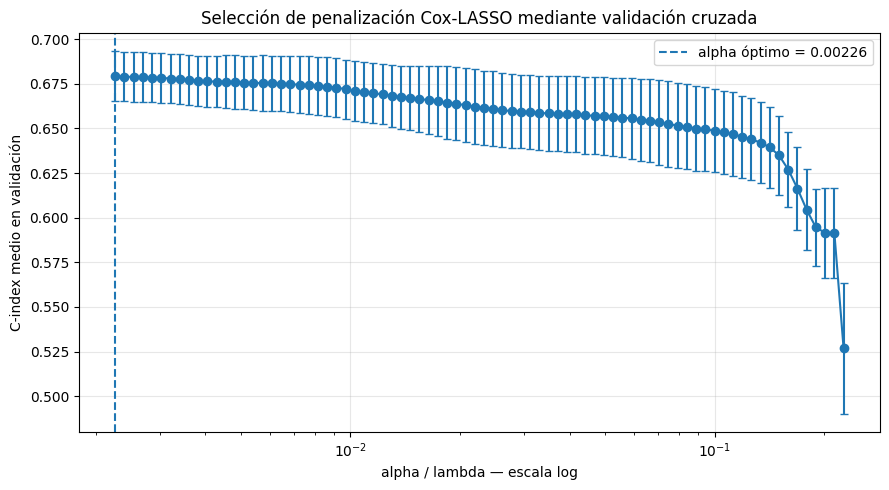

In [36]:
# ── 5. Selección de alpha por CV ─────────────────────────────────────────────
COX_N_ALPHAS = 80
COX_INNER_CV_SPLITS = 5

best_alpha, cox_alpha_summary, cox_alpha_cv_raw, cox_alpha_grid = Cox.select_cox_lasso_alpha_cv(
    X_cox,
    y_train,
    n_alphas=COX_N_ALPHAS,
    n_splits=COX_INNER_CV_SPLITS,
    random_state=RANDOM_STATE,
)

print(f'Mejor alpha Cox-LASSO: {best_alpha:.6g}')
display(cox_alpha_summary.head(10))

Cox.plot_alpha_cv(
    cox_alpha_summary,
    best_alpha=best_alpha,
    save_path=r"..\images\Modelos\Cox\cox_lasso_alpha_cv.png",
)

### **1.2.5. Ajuste del Modelo**

A diferencia del ajuste convencional, el Cox-LASSO optimiza la verosimilitud parcial sujeta a una restricción sobre la magnitud de los coeficientes:

$$\text{Función Objetivo} = \ell_{p}(\beta) - \lambda \sum_{j=1}^{p} |\beta_j|$$

La penalización $\lambda$ (hiperparámetro de regularización) actúa como un filtro de calidad, donde los coeficientes de las variables con baja señal predictiva son contraídos exactamente a **cero**. Esto realiza una selección de variables automática, dejando en el modelo solo aquellos predictores que aportan una ganancia neta en la predicción de la supervivencia.

In [37]:
# ── 6. Ajuste final ──────────────────────────────────────────────────────────
cox_lasso = CoxnetSurvivalAnalysis(
    l1_ratio=1.0,
    alphas=cox_alpha_grid,
    max_iter=100000,
    fit_baseline_model=True,
)
cox_lasso.fit(X_cox, y_train)

coef_cox = Cox.coefficients_table(cox_lasso, X_cox.columns, alpha=best_alpha)

print(f'Variables seleccionadas por Cox-LASSO: {len(coef_cox)} / {X_cox.shape[1]}')
display(coef_cox.head(30))

Variables seleccionadas por Cox-LASSO: 23 / 28


,Variable,coef,HR,abs_coef,Dirección
0,Integrative Cluster_5,0.678926,1.971758,0.678926,↑ riesgo
1,Age at Diagnosis,0.570533,1.769209,0.570533,↑ riesgo
2,Inferred Menopausal State_Pre,0.371916,1.450511,0.371916,↑ riesgo
3,3-Gene classifier subtype_HER2+,-0.342594,0.709926,0.342594,↓ riesgo
4,Pam50 + Claudin-low subtype_claudin-low,-0.267344,0.765409,0.267344,↓ riesgo
5,Lymph nodes examined positive,0.236150,1.266364,0.236150,↑ riesgo
6,Pam50 + Claudin-low subtype_LumA,-0.216464,0.805361,0.216464,↓ riesgo
7,Tumor Stage,0.135715,1.145356,0.135715,↑ riesgo
8,PR Status_Positive,-0.103374,0.901790,0.103374,↓ riesgo
9,Tumor Size,0.103357,1.108887,0.103357,↑ riesgo


### 1.2.6. Visualización de Coeficientes — Forest Plot

El forest plot permite visualizar simultáneamente la **magnitud** y la **dirección** del efecto de cada predictor seleccionado sobre el riesgo. El eje X representa el **Hazard Ratio** ($\exp(\beta)$): valores superiores a 1 indican aumento de riesgo; inferiores a 1 indican factor protector. Los coeficientes se ordenan de mayor a menor efecto absoluto.

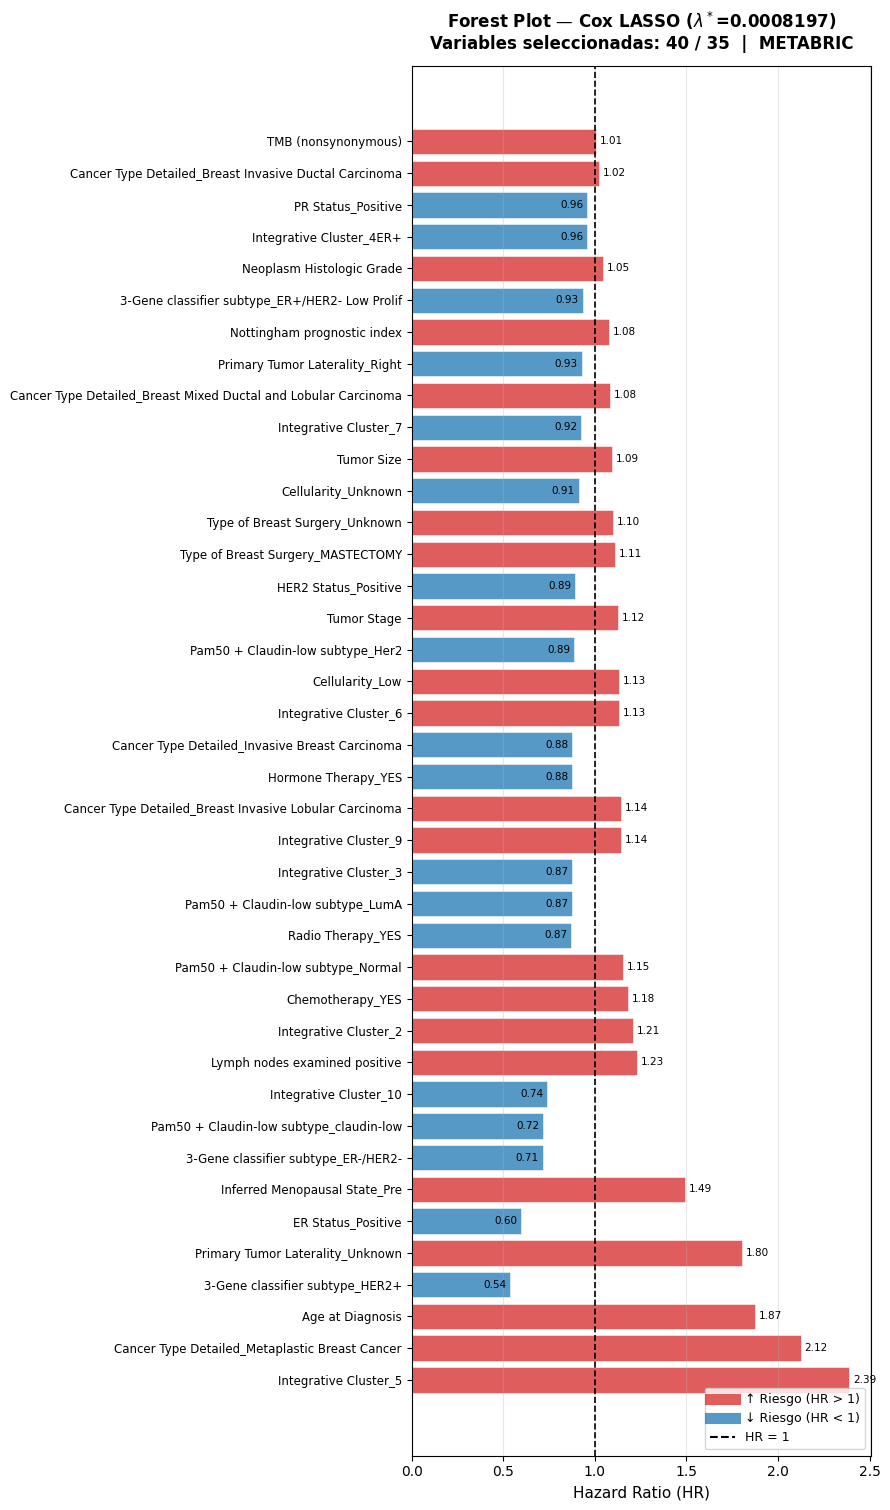

In [17]:
# ── Forest Plot de coeficientes Cox-LASSO ────────────────────────────────────
n_vars  = len(coef_cox)
fig_h   = max(6, n_vars * 0.38)
fig, ax = plt.subplots(figsize=(9, fig_h))

colors = ['#d62728' if hr > 1 else '#1f77b4' for hr in coef_cox['HR']]

ax.barh(
    y     = coef_cox['Variable'],
    width = coef_cox['HR'],
    left  = 0,
    color = colors,
    alpha = 0.75,
    edgecolor = 'white',
    linewidth = 0.5
)

ax.axvline(1, color='black', linewidth=1.2, linestyle='--', label='HR = 1 (sin efecto)')

# Anotaciones de HR
for i, (_, row) in enumerate(coef_cox.iterrows()):
    offset = 0.02 if row['HR'] >= 1 else -0.02
    ha     = 'left' if row['HR'] >= 1 else 'right'
    ax.text(row['HR'] + offset, i, f"{row['HR']:.2f}", va='center', ha=ha, fontsize=7.5)

legend_elements = [
    Line2D([0], [0], color='#d62728', lw=8, alpha=0.75, label='↑ Riesgo (HR > 1)'),
    Line2D([0], [0], color='#1f77b4', lw=8, alpha=0.75, label='↓ Riesgo (HR < 1)'),
    Line2D([0], [0], color='black', lw=1.5, linestyle='--', label='HR = 1'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

ax.set_xlabel('Hazard Ratio (HR)', fontsize=11)
ax.set_title(
    f'Forest Plot — Cox LASSO ($\\lambda^*$={best_alpha:.4g})\n'
    f'Variables seleccionadas: {n_vars} / {X_cox.shape[1]}  |  METABRIC',
    fontsize=12, fontweight='bold', pad=12
)
ax.set_xlim(left=0)
ax.tick_params(axis='y', labelsize=8.5)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(r'../images/Modelos/Cox/cox_lasso_forest_plot.png', dpi=150, bbox_inches='tight')
plt.show()

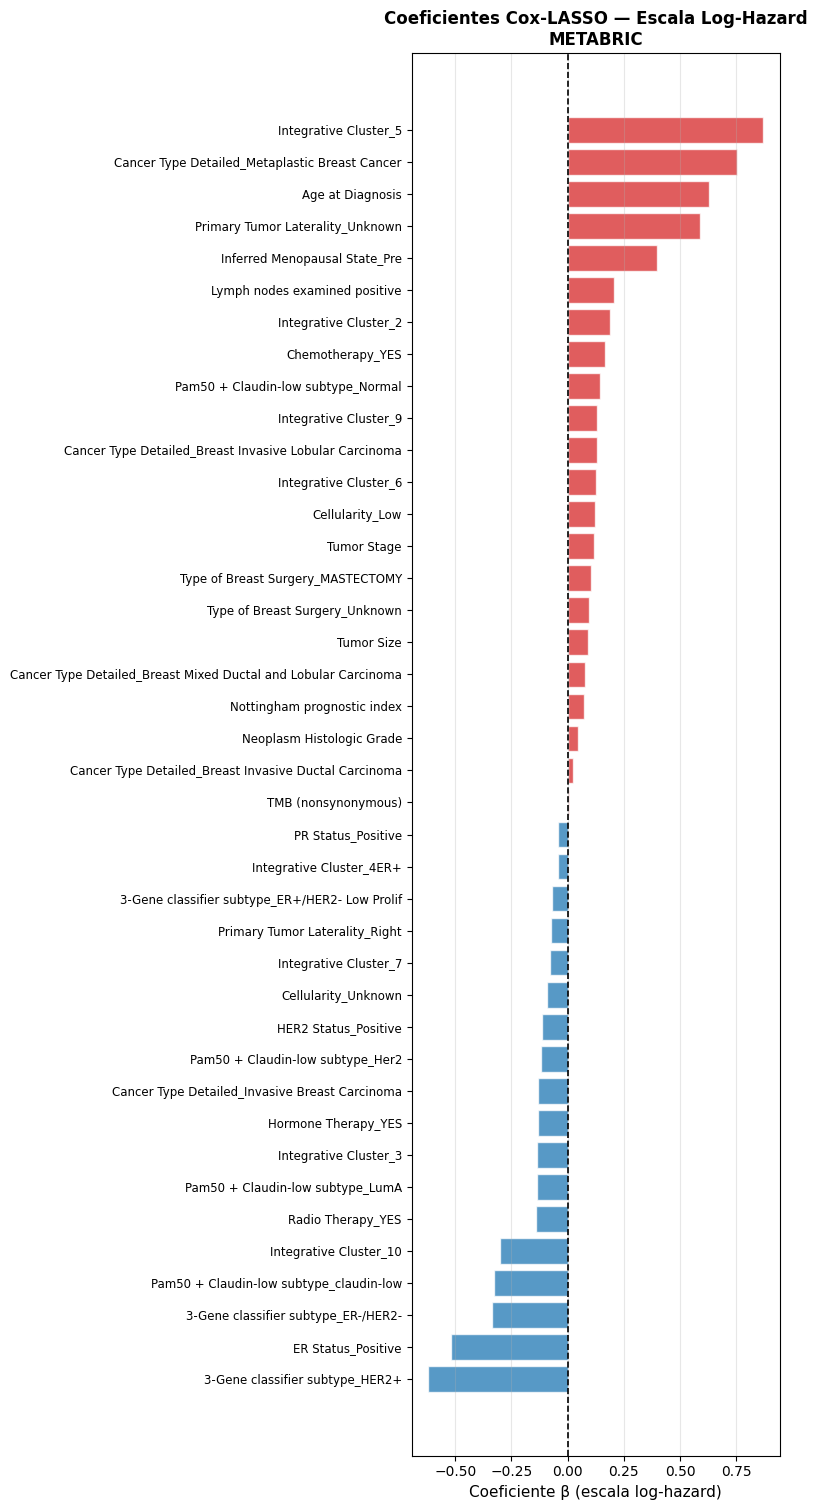

In [18]:
# ── Gráfico de coeficientes β ordenados ─────────────────────────────────────
coef_sorted = coef_cox.sort_values('coef')
colors_coef = ['#d62728' if c > 0 else '#1f77b4' for c in coef_sorted['coef']]

fig, ax = plt.subplots(figsize=(8, fig_h))
ax.barh(coef_sorted['Variable'], coef_sorted['coef'], color=colors_coef, alpha=0.75, edgecolor='white')
ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_xlabel('Coeficiente β (escala log-hazard)', fontsize=11)
ax.set_title('Coeficientes Cox-LASSO — Escala Log-Hazard\nMETABRIC', fontsize=12, fontweight='bold')
ax.tick_params(axis='y', labelsize=8.5)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(r'../images/Modelos/Cox/cox_lasso_coeficientes.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.2.7. Verificación del Supuesto de Riesgos Proporcionales

El modelo Cox asume que los hazard ratios son constantes en el tiempo. Este supuesto puede evaluarse con residuos de Schoenfeld.

Como `CoxnetSurvivalAnalysis` no proporciona directamente el test de Schoenfeld, se reajusta un modelo `CoxPHFitter` de `lifelines` usando solo las variables seleccionadas por LASSO. Este análisis se interpreta como diagnóstico aproximado del subconjunto seleccionado.

> Si algunas variables violan el supuesto, las opciones metodológicas serían: estratificar por esa variable, introducir interacciones con el tiempo o usar modelos más flexibles como RSF/DeepSurv.

#### I. Test de Schoenfeld

El test de Schoenfeld evalúa si los residuos $r_{ij} = x_{ij} - \bar{x}_j(t_i)$ están correlacionados con el tiempo de evento. Bajo riesgos proporcionales:

$$H_0: \text{corr}(r_{ij},\, t_i) = 0 \quad \forall j$$

Un $p < 0.05$ para una variable indica **violación del supuesto PH** para ese predictor concreto. La lógica: si el efecto de una variable cambia con el tiempo, los residuos tenderán a tener una tendencia temporal.

#### II. Interpretación Práctica

Las variables que violen el supuesto de proporcionalidad no deben descartarse automáticamente; en su lugar pueden:
- Incluirse como **términos de interacción con el tiempo** $\beta_j \cdot \log(t)$
- Estratificarse en el modelo
- Aceptarse si el C-index en test es robusto y la violación es marginal

In [43]:
# ── Verificación PH mediante lifelines (requiere CoxPHFitter) ────────────────
# Preparar DataFrame para lifelines (necesita columnas duration y event)
vars_seleccionadas = coef_cox['Variable'].tolist()

df_cox_lifelines = X_cox[vars_seleccionadas].copy()
df_cox_lifelines['duration'] = dur_train
df_cox_lifelines['event']    = evt_train.astype(int)

cph_ll = CoxPHFitter(penalizer=best_alpha)
cph_ll.fit(df_cox_lifelines, duration_col='duration', event_col='event')

# Test de proporcionalidad
results_ph = proportional_hazard_test(cph_ll, df_cox_lifelines, time_transform='rank')

ph_table = results_ph.summary.copy()
ph_table = ph_table.sort_values('p').reset_index()
ph_table.columns = ph_table.columns.str.strip()
ph_table['Cumple PH'] = ph_table['p'] >= 0.05

n_viola = (ph_table['p'] < 0.05).sum()
print(f'Variables que violan PH (p < 0.05): {n_viola} / {len(ph_table)}')
print()
display(ph_table.head(20))

Variables que violan PH (p < 0.05): 4 / 23



,index,test_statistic,p,-log2(p),Cumple PH
0,Age at Diagnosis,17.433957,0.000030,15.036924,False
1,Tumor Stage,8.892142,0.002864,8.447750,False
2,Integrative Cluster_10,8.552638,0.003450,8.179097,False
3,Pam50 + Claudin-low subtype_claudin-low,4.587068,0.032214,4.956165,False
4,Pam50 + Claudin-low subtype_LumB,3.705718,0.054226,4.204863,True
5,PR Status_Positive,3.600759,0.057753,4.113955,True
6,Pam50 + Claudin-low subtype_LumA,3.593363,0.058011,4.107536,True
7,3-Gene classifier subtype_ER+/HER2- Low Prolif,3.177133,0.074676,3.743218,True
8,Integrative Cluster_3,2.896075,0.088796,3.493369,True
9,Neoplasm Histologic Grade,1.059836,0.303253,1.721408,True


#### Interpretación del test de Schoenfeld

El test de Schoenfeld muestra que la mayoría de covariables del Cox-LASSO cumplen razonablemente el supuesto de riesgos proporcionales: 16 de 20 variables presentan `p ≥ 0.05`.

Sin embargo, cuatro variables muestran evidencia de no proporcionalidad temporal:

Sin embargo, cuatro covariables muestran evidencia estadística de violación del supuesto PH:

| Covariable | p-valor | Interpretación |
|---|---:|---|
| `Age at Diagnosis` | 0.000030 | El efecto de la edad no es constante durante todo el seguimiento. |
| `Tumor Stage` | 0.002864 | El impacto del estadio tumoral varía con el tiempo. |
| `Integrative Cluster_10` | 0.003450 | Este subtipo molecular puede tener un patrón de riesgo no proporcional. |
| `Pam50 + Claudin-low subtype_claudin-low` | 0.032214 | El efecto del subtipo claudin-low no parece constante temporalmente. |

Esto indica que sus hazard ratios no deben interpretarse como efectos constantes durante todo el seguimiento, sino como efectos promedio. Es clínicamente plausible, especialmente para edad y estadio tumoral, ya que su impacto puede cambiar entre el riesgo temprano y el riesgo tardío.

Aun así, el modelo Cox-LASSO sigue siendo válido como modelo multivariante interpretable, aunque estas violaciones parciales justifican comparar posteriormente con modelos más flexibles como RSF y DeepSurv.

### 1.2.8. Evaluación del Modelo — Métricas de Discriminación y Calibración

Se evalúa el modelo con métricas complementarias:

#### I. C-index (Harrell)

$$
C = P(\eta_i > \eta_j \mid T_i < T_j)
$$

Interpretación aproximada:

- 0.50: discriminación aleatoria.
- 0.60–0.70: discriminación moderada.
- 0.70–0.80: buena discriminación para datos clínicos observacionales.
- >0.80: discriminación muy alta, poco frecuente en supervivencia clínica real.

#### II. Integrated Brier Score (IBS)

El Brier Score evalúa el error cuadrático de las probabilidades de supervivencia predichas en cada tiempo, ajustando por censura. El Integrated Brier Score resume esa curva en un único valor. Valores menores indican mejor desempeño.

Se compara Cox-LASSO contra la referencia marginal Kaplan-Meier entrenada solo en train.

In [56]:
# ── C-index en train y test ──────────────────────────────────────────────────
eta_train = cox_lasso.predict(X_cox)
eta_test  = cox_lasso.predict(X_cox_test)

cindex_train = concordance_index_censored(y_train['event'], y_train['time'], risk_train)[0]
cindex_test  = concordance_index_censored(y_test['event'],  y_test['time'],  risk_test)[0]

print(f'C-index train : {cindex_train:.4f}')
print(f'C-index test  : {cindex_test:.4f}')
print(f'Diferencia    : {cindex_train - cindex_test:.4f}  (sobreajuste estimado)')

C-index train : 0.6864
C-index test  : 0.6761
Diferencia    : 0.0104  (sobreajuste estimado)


In [57]:
# ── 9. Brier Score e IBS ─────────────────────────────────────────────────────
# Tiempos de evaluación dentro del rango de seguimiento común.
times_eval = np.percentile(y_train['time'], np.linspace(10, 90, 80))
times_eval = np.unique(times_eval)
times_eval = times_eval[
    (times_eval > y_test['time'].min()) &
    (times_eval < y_test['time'].max()) &
    (times_eval < y_train['time'].max())
]

# Supervivencia individual predicha por Cox-LASSO.
surv_fns_test = cox_lasso.predict_survival_function(X_cox_test, alpha=best_alpha)
surv_probs_cox = np.asarray([[fn(t) for t in times_eval] for fn in surv_fns_test])

_, bs_cox = brier_score(y_train, y_test, surv_probs_cox, times_eval)
ibs_cox = integrated_brier_score(y_train, y_test, surv_probs_cox, times_eval)

# Referencia marginal Kaplan-Meier ajustada SOLO en train.
kmf_train = KaplanMeierFitter()
kmf_train.fit(dur_train, evt_train, label='KM train marginal')
km_surv_probs = np.tile(kmf_train.predict(times_eval).values, (len(y_test), 1))

_, bs_km = brier_score(y_train, y_test, km_surv_probs, times_eval)
ibs_km = integrated_brier_score(y_train, y_test, km_surv_probs, times_eval)

metrics_eval = pd.DataFrame({
    'Modelo': ['Kaplan-Meier marginal', 'Cox-LASSO'],
    'C-index test': [np.nan, cindex_test],
    'IBS test': [ibs_km, ibs_cox],
    'Mejora IBS vs KM': [np.nan, ibs_km - ibs_cox],
})

display(metrics_eval)


,Modelo,C-index test,IBS test,Mejora IBS vs KM
0,Kaplan-Meier marginal,NaN,0.217739,NaN
1,Cox-LASSO,0.676065,0.186344,0.031395


#### Interpretación de las métricas predictivas

El modelo Cox-LASSO obtiene un C-index en test de **0.676**, lo que indica una capacidad discriminativa moderada. Esto significa que, en aproximadamente el 67.6% de los pares de pacientes comparables, el modelo asigna mayor riesgo al paciente que experimenta antes el evento.

En términos de calibración temporal, el Cox-LASSO alcanza un **Integrated Brier Score (IBS) de 0.186**, frente a **0.218** del modelo Kaplan-Meier marginal. La mejora absoluta es de **0.031 puntos**, equivalente a una reducción relativa aproximada del **14.4%** respecto a la referencia no individualizada.

Estos resultados muestran que el uso de covariables clínicas y moleculares aporta valor predictivo real frente a asignar la misma curva de supervivencia a todos los pacientes. Por tanto, el Cox-LASSO mejora tanto la individualización del riesgo como la precisión temporal de las predicciones de supervivencia.

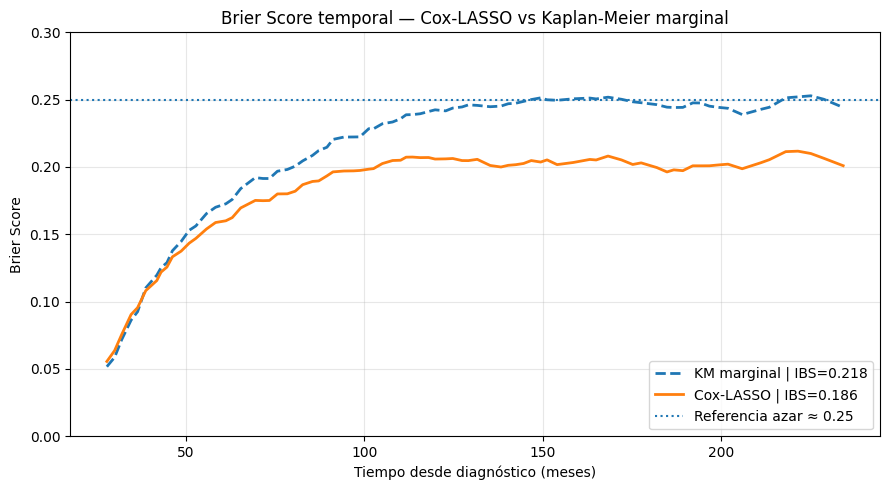

In [58]:

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(times_eval, bs_km, linestyle='--', linewidth=2, label=f'KM marginal | IBS={ibs_km:.3f}')
ax.plot(times_eval, bs_cox, linewidth=2, label=f'Cox-LASSO | IBS={ibs_cox:.3f}')
ax.axhline(0.25, linestyle=':', linewidth=1.5, label='Referencia azar ≈ 0.25')
ax.set_xlabel('Tiempo desde diagnóstico (meses)')
ax.set_ylabel('Brier Score')
ax.set_title('Brier Score temporal — Cox-LASSO vs Kaplan-Meier marginal')
ax.set_ylim(0, max(0.30, float(np.nanmax([bs_km.max(), bs_cox.max()])) + 0.02))
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(r'../images/Modelos/Cox/cox_lasso_brier_vs_km.png', dpi=150, bbox_inches='tight')
plt.show()

### **1.2.10. Interpretación completa del modelo Cox-LASSO**

El modelo Cox-LASSO identifica un conjunto de predictores asociados al riesgo individual de muerte en METABRIC. La penalización LASSO permite reducir el ruido del modelo, seleccionar variables relevantes y controlar parcialmente la colinealidad generada por variables clínicas relacionadas y codificación one-hot.

#### I. Variables asociadas a mayor riesgo

Las variables con mayor asociación positiva con el riesgo fueron:

| Variable | HR | Interpretación |
|---|---:|---|
| `Integrative Cluster_5` | 1.97 | Subgrupo molecular asociado a peor pronóstico. |
| `Age at Diagnosis` | 1.77 | Mayor edad al diagnóstico aumenta el riesgo de muerte. |
| `Inferred Menopausal State_Pre` | 1.45 | Asociación positiva con el riesgo en el modelo ajustado. |
| `Lymph nodes examined positive` | 1.27 | Mayor afectación ganglionar implica peor pronóstico. |
| `Tumor Stage` | 1.15 | Estadios más avanzados aumentan el riesgo. |
| `Tumor Size` | 1.11 | Tumores de mayor tamaño se asocian con mayor riesgo. |
| `Neoplasm Histologic Grade` | 1.09 | Mayor grado histológico indica mayor agresividad tumoral. |

Estos resultados son clínicamente coherentes. La edad, el estadio tumoral, el tamaño del tumor, el grado histológico y la afectación ganglionar son factores pronósticos clásicos en cáncer de mama. Su selección por LASSO confirma que el modelo recupera señales clínicas esperadas.

Destaca especialmente `Integrative Cluster_5`, que presenta el mayor HR del modelo. Esto sugiere que la información molecular integrada añade valor pronóstico adicional más allá de las variables clínicas clásicas.

#### II. Variables asociadas a menor riesgo

Entre las variables con HR inferior a 1 destacan:

| Variable | HR | Interpretación |
|---|---:|---|
| `3-Gene classifier subtype_HER2+` | 0.71 | Asociación con menor riesgo relativo frente a la categoría de referencia. |
| `Pam50 + Claudin-low subtype_claudin-low` | 0.77 | Efecto protector relativo en el modelo ajustado. |
| `Pam50 + Claudin-low subtype_LumA` | 0.81 | Subtipo Luminal A asociado a mejor pronóstico. |
| `PR Status_Positive` | 0.90 | La positividad de PR se asocia con menor riesgo. |
| `Pam50 + Claudin-low subtype_LumB` | 0.91 | Menor riesgo relativo frente a la referencia. |
| `Integrative Cluster_3` | 0.91 | Subgrupo molecular con mejor pronóstico relativo. |
| `Integrative Cluster_10` | 0.92 | Efecto protector promedio en el modelo. |

La selección de `Pam50_LumA` como variable protectora es consistente con la biología del cáncer de mama, ya que los tumores Luminal A suelen presentar evolución más lenta y mejor supervivencia. La positividad de PR también es coherente con un fenotipo hormonal más favorable.

Algunas variables moleculares presentan interpretaciones dependientes de la categoría de referencia utilizada por el one-hot encoding. Por ello, los hazard ratios de subtipos concretos deben interpretarse como efectos relativos respecto a la categoría omitida, no como efectos absolutos del subtipo.

#### III. Rendimiento predictivo

El modelo alcanza un **C-index test de 0.676**, lo que indica discriminación moderada. Es decir, en aproximadamente el 67.6% de los pares comparables, el modelo asigna mayor riesgo al paciente que experimenta antes el evento.

La diferencia entre train y test es pequeña:

$$
0.686 - 0.676 = 0.010
$$

Esto sugiere que la penalización LASSO controla adecuadamente el sobreajuste.

En calibración temporal, el Cox-LASSO obtiene un **IBS de 0.186**, frente a **0.218** del Kaplan-Meier marginal. La mejora absoluta es de **0.031**, equivalente a una reducción relativa aproximada del **14.4%**. Esto demuestra que el modelo individualizado mejora claramente frente a asignar la misma curva de supervivencia a todos los pacientes.

#### IV. Supuesto de riesgos proporcionales

El test de Schoenfeld muestra que la mayoría de variables cumplen razonablemente el supuesto de riesgos proporcionales. Sin embargo, cuatro covariables presentan evidencia de no proporcionalidad temporal:

- `Age at Diagnosis`
- `Tumor Stage`
- `Integrative Cluster_10`
- `Pam50 + Claudin-low subtype_claudin-low`

Esto implica que sus hazard ratios deben interpretarse como efectos promedio durante el seguimiento, no como efectos constantes en todos los instantes temporales.

Esta limitación es clínicamente plausible. En cáncer de mama, algunos factores tienen mayor impacto en el riesgo temprano, mientras que otros influyen más en eventos tardíos. Por tanto, la violación parcial del supuesto PH no invalida el modelo, pero sí justifica la comparación posterior con modelos más flexibles como Random Survival Forest y DeepSurv.

#### V. Conclusión interpretativa

El Cox-LASSO ofrece un equilibrio adecuado entre interpretabilidad y capacidad predictiva. Selecciona variables clínicamente plausibles, mejora al modelo Kaplan-Meier marginal y mantiene bajo control el sobreajuste.

No obstante, su estructura lineal y el supuesto de riesgos proporcionales limitan su capacidad para capturar efectos temporales complejos, interacciones no lineales y cambios de riesgo a largo plazo. Por ello, debe entenderse como un modelo multivariante base sólido, pero no necesariamente como el modelo final óptimo.

### **1.2.9. Resumen ejecutivo — Cox-LASSO**

El modelo Cox con penalización LASSO se utilizó como primer modelo multivariante e interpretable para estimar el riesgo individual de muerte en la cohorte METABRIC. Tras el filtrado clínico, estadístico y estructural de variables, el conjunto inicial de **56 covariables** se redujo a **28 covariables candidatas** para el modelo penalizado.

La selección del hiperparámetro de regularización mediante validación cruzada estratificada identificó como óptimo:

$$
\alpha^* = 0.002261
$$

Con este nivel de penalización, el modelo seleccionó **23 variables de 28**, manteniendo principalmente predictores clínicos clásicos, variables de carga tumoral y subtipos moleculares.

Los resultados predictivos en test fueron:

| Métrica | Resultado |
|---|---:|
| C-index train | 0.686 |
| C-index test | 0.676 |
| Diferencia train-test | 0.010 |
| IBS Kaplan-Meier marginal | 0.218 |
| IBS Cox-LASSO | 0.186 |
| Mejora absoluta IBS vs KM | 0.031 |
| Mejora relativa IBS vs KM | ≈14.4% |

El C-index en test de **0.676** indica una capacidad discriminativa moderada. La diferencia reducida entre train y test sugiere que el modelo no presenta sobreajuste relevante. Además, el Cox-LASSO mejora claramente al modelo Kaplan-Meier marginal, reduciendo el Integrated Brier Score de **0.218** a **0.186**.

En conjunto, el Cox-LASSO demuestra que las covariables clínicas y moleculares aportan valor predictivo real frente a una referencia no individualizada, manteniendo al mismo tiempo un grado alto de interpretabilidad.

### **1.2.11. Respuesta a la pregunta de investigación — Cox-LASSO**

> **¿Aporta un modelo Cox penalizado con LASSO valor predictivo e interpretativo para estimar la supervivencia global individual en la cohorte METABRIC?**

Sí. El modelo Cox-LASSO aporta valor predictivo e interpretativo frente al análisis Kaplan-Meier marginal.

Desde el punto de vista predictivo, el Cox-LASSO alcanza un **C-index en test de 0.676**, lo que indica una capacidad moderada para ordenar correctamente a los pacientes según su riesgo de muerte. Además, obtiene un **IBS de 0.186**, mejorando al Kaplan-Meier marginal, cuyo IBS fue de **0.218**. La mejora absoluta de **0.031 puntos** equivale a una reducción relativa aproximada del **14.4%** en el error de predicción temporal.

Estos resultados demuestran que el uso de covariables clínicas y moleculares permite individualizar mejor el riesgo que una estrategia no ajustada, donde todos los pacientes reciben la misma curva de supervivencia.

Desde el punto de vista interpretativo, el modelo selecciona predictores coherentes con el conocimiento clínico del cáncer de mama, como la edad al diagnóstico, afectación ganglionar, estadio tumoral, tamaño tumoral, grado histológico y subtipos moleculares. Esto confirma que el modelo no solo mejora la predicción, sino que también recupera factores pronósticos biológicamente plausibles.

Sin embargo, el test de Schoenfeld muestra que algunas covariables violan parcialmente el supuesto de riesgos proporcionales. Por tanto, los hazard ratios de esas variables deben interpretarse como efectos promedio durante el seguimiento. Esta limitación no invalida el modelo, pero sí indica que pueden existir patrones temporales y no lineales que Cox-LASSO no captura completamente.

En conclusión, el Cox-LASSO constituye un modelo multivariante robusto, interpretable y predictivamente superior al Kaplan-Meier marginal. No obstante, sus limitaciones metodológicas justifican avanzar hacia modelos más flexibles, como Random Survival Forest y DeepSurv, para evaluar si capturan mejor la complejidad pronóstica de METABRIC.